# 📊 01 – EDA: GTZAN Adatfeltárás

Cél: az adathalmaz megismerése, minőség-ellenőrzés, spektrogramok vizsgálata.
Minden megfigyelést jegyezz fel a vault `01_EDA.md` fájlban!

In [1]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('../data/genres_original')
GENRES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
SR = 22050

print('Műfajok:', GENRES)
print('Összesen:', sum(len(list((DATA_DIR/g).glob('*.wav'))) for g in GENRES), 'fájl')

Műfajok: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Összesen: 1000 fájl


## 1. Osztályeloszlás

/tmp/ipykernel_2877544/3854175353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Műfaj', y='Fájlok', ax=ax, palette='viridis')


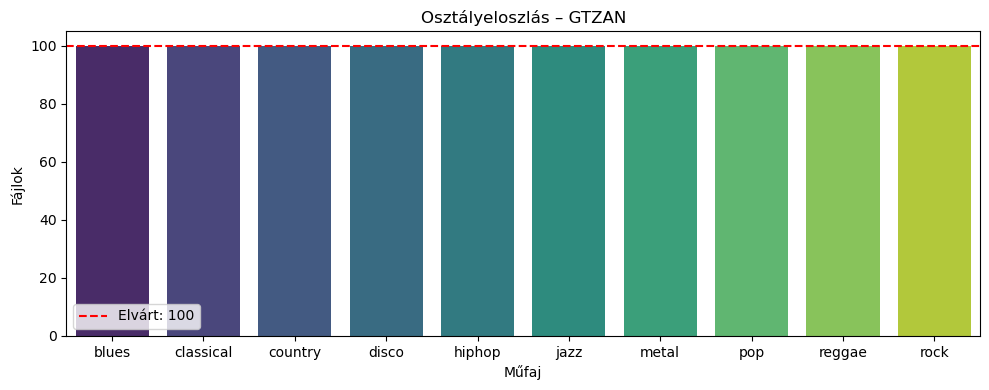

    Műfaj  Fájlok
    blues     100
classical     100
  country     100
    disco     100
   hiphop     100
     jazz     100
    metal     100
      pop     100
   reggae     100
     rock     100


In [2]:
counts = {g: len(list((DATA_DIR/g).glob('*.wav'))) for g in GENRES}
df_counts = pd.DataFrame(counts.items(), columns=['Műfaj', 'Fájlok'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_counts, x='Műfaj', y='Fájlok', ax=ax, palette='viridis')
ax.axhline(100, color='red', linestyle='--', label='Elvárt: 100')
ax.set_title('Osztályeloszlás – GTZAN')
ax.legend()
plt.tight_layout()
plt.show()

print(df_counts.to_string(index=False))

## 2. Adatintegritás – hossz és mintavételi frekvencia ellenőrzés

In [3]:
records = []
errors = []

for genre in GENRES:
    for wav_path in sorted((DATA_DIR/genre).glob('*.wav')):
        try:
            info = librosa.get_duration(path=str(wav_path))
            y, sr = librosa.load(str(wav_path), sr=None, duration=1.0)  # csak 1s a sebességért
            records.append({'genre': genre, 'file': wav_path.name,
                            'duration': round(info, 2), 'sr': sr})
        except Exception as e:
            errors.append({'file': str(wav_path), 'error': str(e)})

df_meta = pd.DataFrame(records)
print('=== Hibás fájlok ===')
print(pd.DataFrame(errors) if errors else 'Nincs hibás fájl ✅')
print()
print('=== Hossz statisztika (másodperc) ===')
print(df_meta.groupby('genre')['duration'].describe().round(2))
print()
print('=== Mintavételi frekvenciák ===')
print(df_meta['sr'].value_counts())

/tmp/ipykernel_2877544/127702429.py:7: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  info = librosa.get_duration(path=str(wav_path))


=== Hibás fájlok ===
                                          file error
0  ../data/genres_original/jazz/jazz.00054.wav      

=== Hossz statisztika (másodperc) ===
           count   mean   std    min    25%    50%    75%    max
genre                                                           
blues      100.0  30.01  0.00  30.01  30.01  30.01  30.01  30.01
classical  100.0  30.02  0.07  29.99  30.01  30.01  30.01  30.49
country    100.0  30.02  0.05  29.98  30.01  30.01  30.01  30.37
disco      100.0  30.02  0.06  29.99  30.00  30.00  30.01  30.30
hiphop     100.0  30.09  0.20  29.93  30.01  30.01  30.01  30.65
jazz        99.0  30.03  0.08  30.01  30.01  30.01  30.01  30.48
metal      100.0  30.00  0.00  30.00  30.00  30.00  30.01  30.01
pop        100.0  30.00  0.00  30.00  30.00  30.00  30.00  30.00
reggae     100.0  30.00  0.00  30.00  30.00  30.00  30.01  30.01
rock       100.0  30.02  0.06  30.00  30.01  30.01  30.01  30.40

=== Mintavételi frekvenciák ===
sr
22050    999
Name:

In [4]:
# Gyanús fájlok: eltérő hossz vagy SR
EXPECTED_DUR = 30.0
EXPECTED_SR  = 22050
suspicious = df_meta[(df_meta['duration'] < EXPECTED_DUR - 1) |
                     (df_meta['sr'] != EXPECTED_SR)]
print('Gyanús fájlok:', len(suspicious))
print(suspicious[['genre','file','duration','sr']])

Gyanús fájlok: 0
Empty DataFrame
Columns: [genre, file, duration, sr]
Index: []


## 3. Waveform és Mel-spektrogram vizsgálat

/tmp/ipykernel_2877544/3617317561.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


NameError: name 'OUTPUT_DIR' is not defined

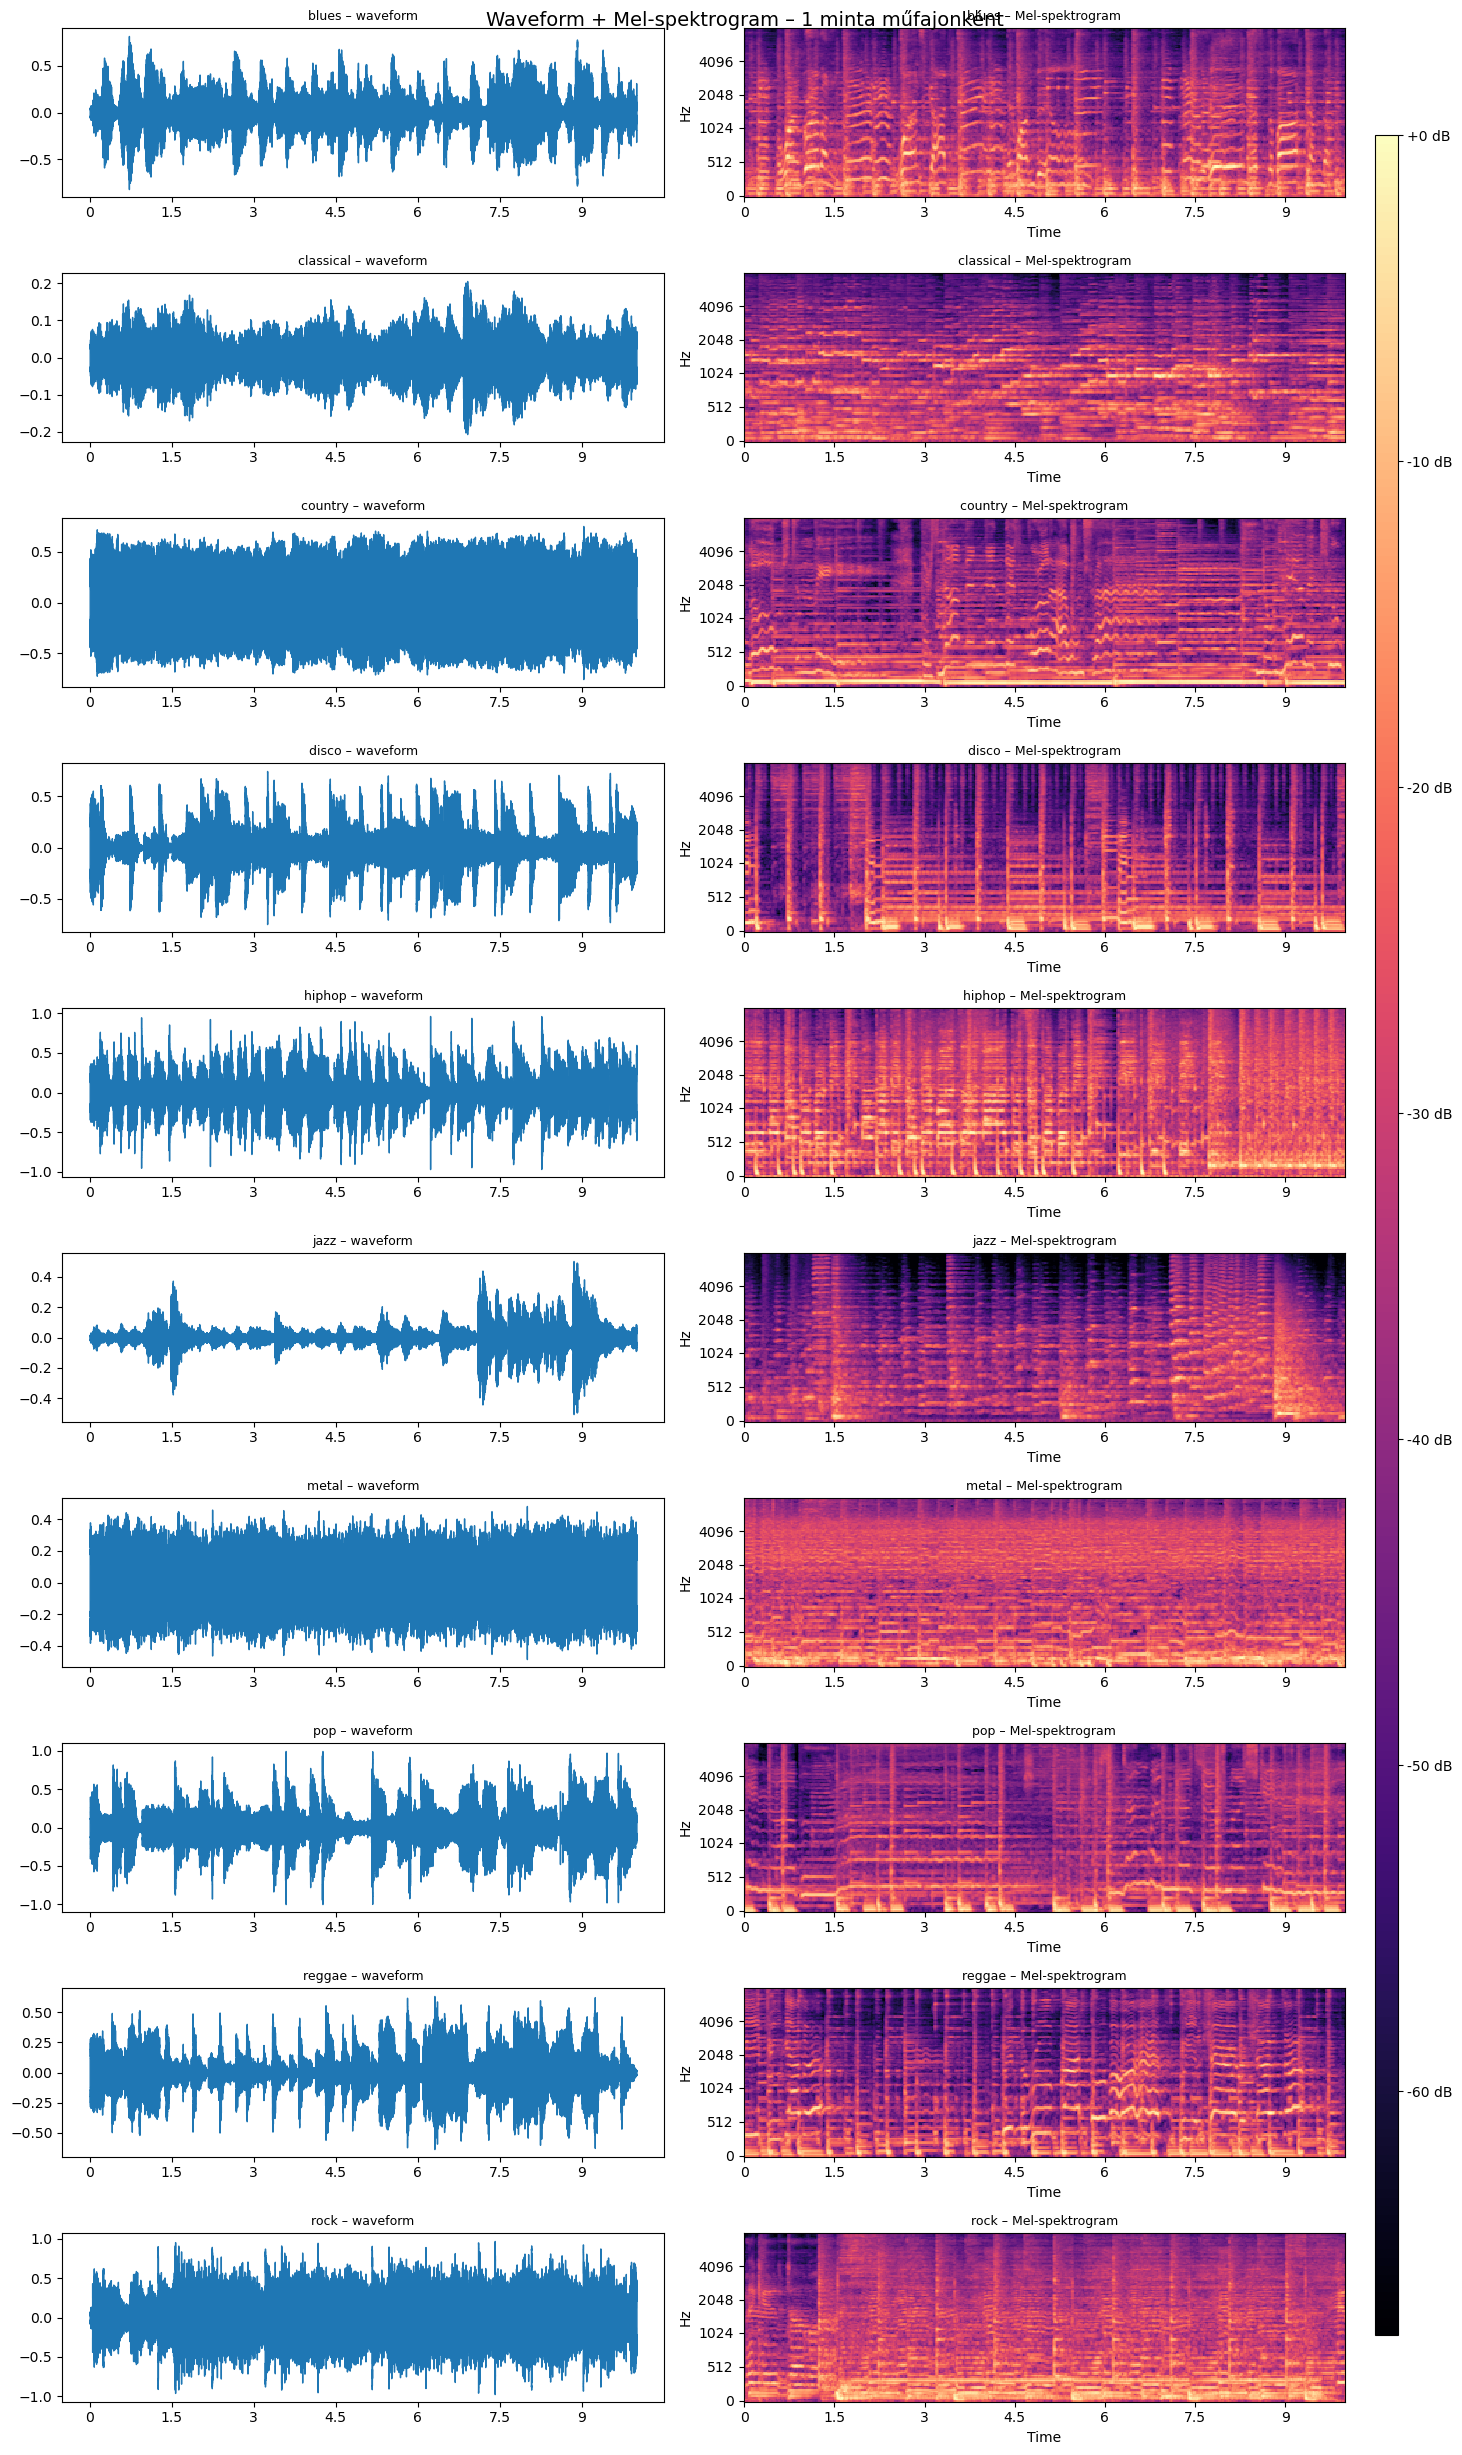

In [5]:
fig, axes = plt.subplots(len(GENRES), 2, figsize=(15, len(GENRES)*2.5),
                         gridspec_kw={'width_ratios': [1, 1]})
fig.suptitle('Waveform + Mel-spektrogram – 1 minta műfajonként', fontsize=14)

for i, genre in enumerate(GENRES):
    sample = sorted((DATA_DIR/genre).glob('*.wav'))[0]
    y, sr = librosa.load(str(sample), sr=SR, duration=10.0)

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f'{genre} – waveform', fontsize=9)
    axes[i, 0].set_xlabel('')

    # Mel-spektrogram
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(
        mel_db, sr=sr,
        x_axis='time', y_axis='mel',
        ax=axes[i, 1], fmax=8000
    )
    axes[i, 1].set_title(f'{genre} – Mel-spektrogram', fontsize=9)

# Colorbar: a fig jobb szélén, egy önálló helyen
# fig.add_axes([bal, lent, szélesség, magasság]) – értékek 0–1 között, az egész fig-hez képest
cbar_ax = fig.add_axes([0.92, 0.05, 0.015, 0.88])  # vékony sáv a jobb szélen
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

# tight_layout-ot csak a bal részig alkalmazzuk, helyet hagyva a colorbar-nak
plt.tight_layout(rect=[0, 0, 0.91, 1])

out_path = OUTPUT_DIR / 'eda_mel_spectrograms.png'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'Kép mentve: {out_path}')

## 4. CSV feature-ök vizsgálata (Baseline ML-hez)

In [ ]:
csv_path = Path('../data/features_30_sec.csv')
df_feat = pd.read_csv(csv_path)
print('Alakja:', df_feat.shape)
print('Oszlopok:', df_feat.columns.tolist()[:10], '...')
print()
print('Osztályeloszlás:')
print(df_feat['label'].value_counts())
print()
print('Hiányzó értékek:')
print(df_feat.isnull().sum().sum(), 'db')
print()
df_feat.head(3)

Alakja: (1000, 60)
Oszlopok: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var'] ...

Osztályeloszlás:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64

Hiányzó értékek:
0 db



,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues


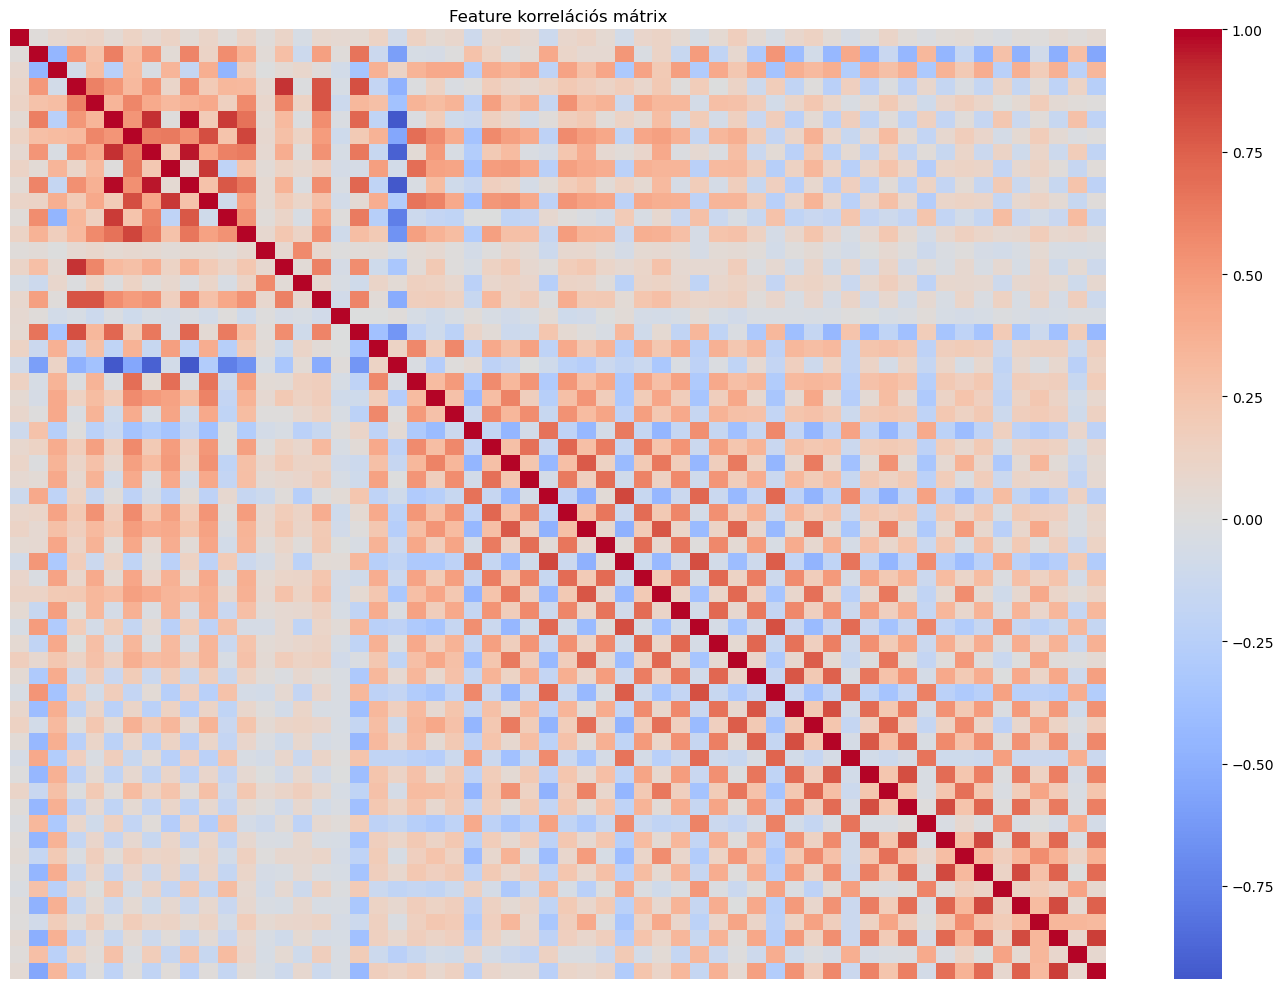

In [ ]:
# Feature korrelációs heatmap (MFCC-k és egyéb jellemzők)
numeric_cols = df_feat.select_dtypes(include=np.number).columns
corr = df_feat[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title('Feature korrelációs mátrix')
plt.tight_layout()
plt.show()

/tmp/ipykernel_316/1428636296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='label', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_316/1428636296.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_316/1428636296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='label', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_316/1428636296.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(

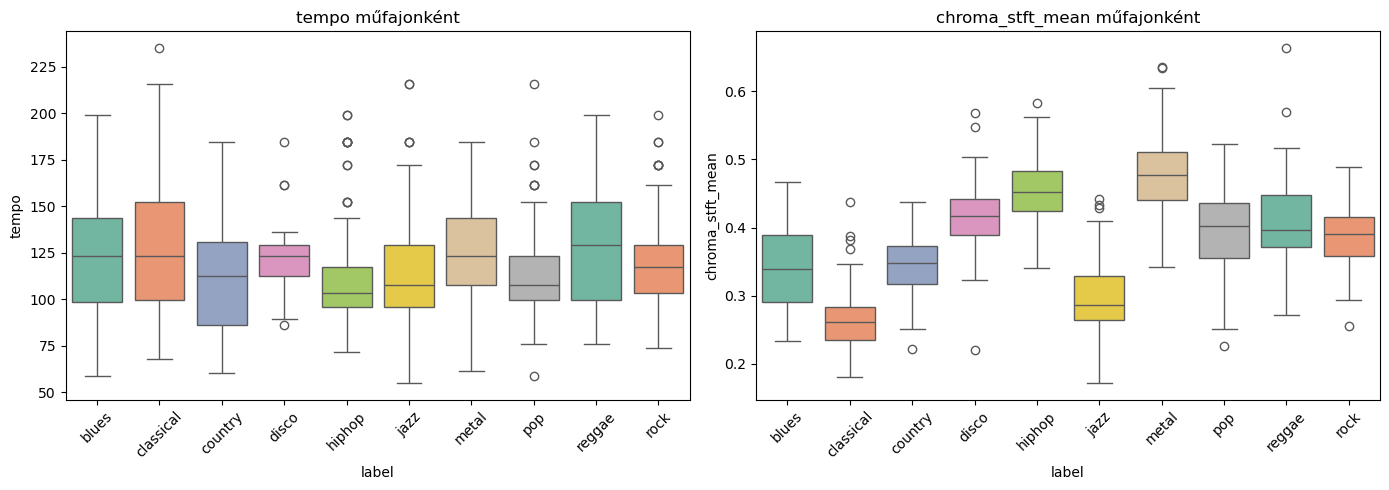

In [ ]:
# Boxplot: chroma_mean és tempo műfajonként
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['tempo', 'chroma_stft_mean']):
    if col in df_feat.columns:
        sns.boxplot(data=df_feat, x='label', y=col, ax=ax, palette='Set2')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.set_title(f'{col} műfajonként')

plt.tight_layout()
plt.show()

## 5. EDA összefoglalás – vault-ba másolandó

A cell futtatása után másold az eredményeket a `01_Projects/Uni/GTZAN-mufajfelismeres/01_EDA.md` fájlba.

In [ ]:
print('=== EDA ÖSSZEFOGLALÓ ===')
print(f'Összes fájl: {len(df_meta)}')
print(f'Hibás fájlok: {len(errors)}')
print(f'Gyanús fájlok (eltérő hossz/SR): {len(suspicious)}')
print(f'CSV feature sorok: {len(df_feat)}')
print(f'CSV feature oszlopok: {len(df_feat.columns)}')
print()
print('Következő lépés: 02_Baseline_ML.ipynb')

=== EDA ÖSSZEFOGLALÓ ===
Összes fájl: 999
Hibás fájlok: 1
Gyanús fájlok (eltérő hossz/SR): 0
CSV feature sorok: 1000
CSV feature oszlopok: 60

Következő lépés: 02_Baseline_ML.ipynb
